## Emotion Detection from Text using TF-IDF and BERT
This project implements emotion detection from text using:

1. Traditional Machine Learning (TF-IDF + Logistic Regression) 
2. Context-aware Deep Learning (BERT)

## STEP 1: Import Required Libraries¶

In [3]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [4]:
# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## STEP 2: Load Dataset

In [6]:
# Load dataset
df = pd.read_csv("tweet_emotions.csv")

# Show first 5 rows
df.head()

,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...


In [7]:
# Dataset shape
df.shape


(40000, 3)

In [8]:
# Column names
df.columns


Index(['tweet_id', 'sentiment', 'content'], dtype='object')

## STEP 3: Keep Required Columns Only

In [9]:
df = df[['content', 'sentiment']]
df.head()


,content,sentiment
0,@tiffanylue i know i was listenin to bad habi...,empty
1,Layin n bed with a headache ughhhh...waitin o...,sadness
2,Funeral ceremony...gloomy friday...,sadness
3,wants to hang out with friends SOON!,enthusiasm
4,@dannycastillo We want to trade with someone w...,neutral


## Step - 4 Basic Data Exploration (EDA)

In [10]:
# Check missing values
df.isnull().sum()


content      0
sentiment    0
dtype: int64

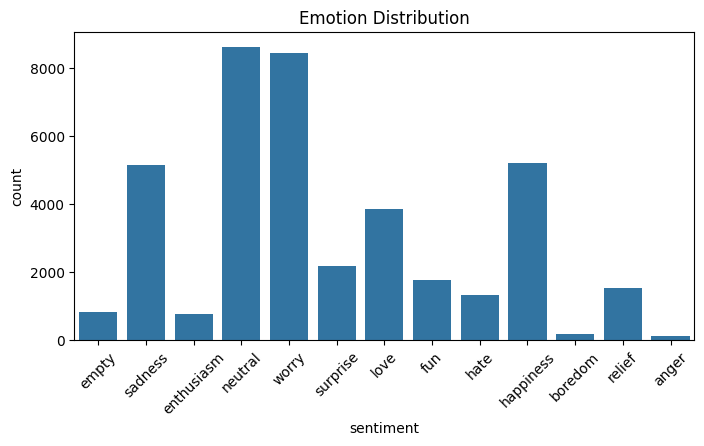

In [11]:
# Emotion distribution
plt.figure(figsize=(8,4))
sns.countplot(x='sentiment', data=df)
plt.xticks(rotation=45)
plt.title("Emotion Distribution")
plt.show()


## STEP 5: Text Preprocessing (VERY IMPORTANT)

#### Text Preprocessing
Steps:
- Lowercasing
- Removing URLs & punctuation
- Stopword removal
- Lemmatization


In [12]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)


In [13]:
df['clean_text'] = df['content'].apply(clean_text)
df[['content', 'clean_text']].head()


,content,clean_text
0,@tiffanylue i know i was listenin to bad habi...,tiffanylue know listenin bad habit earlier sta...
1,Layin n bed with a headache ughhhh...waitin o...,layin n bed headache ughhhhwaitin call
2,Funeral ceremony...gloomy friday...,funeral ceremonygloomy friday
3,wants to hang out with friends SOON!,want hang friend soon
4,@dannycastillo We want to trade with someone w...,dannycastillo want trade someone houston ticke...


## STEP 6: Encode Sentiment Labels

In [14]:
le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])

df[['sentiment', 'sentiment_encoded']].head()


,sentiment,sentiment_encoded
0,empty,2
1,sadness,10
2,sadness,10
3,enthusiasm,3
4,neutral,8


## STEP 7: Train-Test Split

In [15]:
X = df['clean_text']
y = df['sentiment_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## STEP 8: TF-IDF Vectorization

In [16]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


## STEP 9: Logistic Regression Model

In [17]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000)

## STEP 10: Evaluation

In [18]:
y_pred = lr_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Accuracy: 0.346

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        22
           1       0.00      0.00      0.00        36
           2       0.00      0.00      0.00       165
           3       0.00      0.00      0.00       152
           4       0.30      0.04      0.07       355
           5       0.33      0.35      0.34      1042
           6       0.41      0.11      0.17       265
           7       0.51      0.40      0.45       768
           8       0.33      0.56      0.41      1728
           9       0.25      0.03      0.06       305
          10       0.35      0.26      0.30      1033
          11       0.26      0.03      0.06       437
          12       0.34      0.47      0.40      1692

    accuracy                           0.35      8000
   macro avg       0.24      0.17      0.17      8000
weighted avg       0.33      0.35      0.31      8000



C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

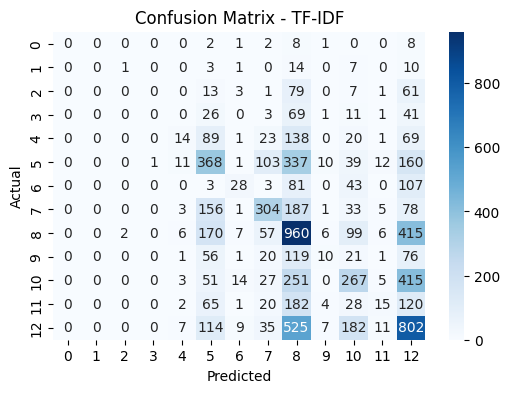

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - TF-IDF")
plt.show()


#### 
- The TF-IDF based model serves as a baseline.
- Due to lack of contextual understanding and overlapping emotional expressions,
- the model achieves moderate accuracy.
- This motivates the use of a context-aware transformer-based model.


## STEP 11: Install & Import BERT Libraries

In [20]:
!pip install transformers torch --quiet

In [21]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup


## STEP 12: Prepare Data for BERT

In [22]:
# Use RAW text for BERT
texts = df['content'].values
labels = df['sentiment_encoded'].values


In [23]:
X_train_text, X_test_text, y_train_bert, y_test_bert = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)


## STEP 13: Load BERT Tokenizer

In [24]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

## STEP 14: Create Custom Dataset Class

In [25]:
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }


## STEP 15: Create DataLoaders

In [26]:
train_dataset = EmotionDataset(X_train_text, y_train_bert, tokenizer)
test_dataset  = EmotionDataset(X_test_text, y_test_bert, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16)


## STEP 16: Load Pretrained BERT Model

In [27]:
num_classes = len(df['sentiment'].unique())

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_classes
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

## STEP 17: Optimizer & Scheduler

In [28]:
optimizer = AdamW(model.parameters(), lr=2e-5)

total_steps = len(train_loader) * 3  # 3 epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)


## STEP 18: Training Loop (Fine-Tuning BERT)

In [29]:
epochs = 1

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for i, batch in enumerate(train_loader):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        
        optimizer.step()
        scheduler.step()

        if i % 50 == 0:
            print(f"Batch {i}/{len(train_loader)} - Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} done - Avg Loss: {avg_loss:.4f}")


Batch 0/2000 - Loss: 2.4782
Batch 50/2000 - Loss: 2.1778
Batch 100/2000 - Loss: 2.1649
Batch 150/2000 - Loss: 1.8150
Batch 200/2000 - Loss: 1.7043
Batch 250/2000 - Loss: 2.0057
Batch 300/2000 - Loss: 1.7884
Batch 350/2000 - Loss: 1.6745
Batch 400/2000 - Loss: 2.0877
Batch 450/2000 - Loss: 1.6115
Batch 500/2000 - Loss: 2.4004
Batch 550/2000 - Loss: 2.2894
Batch 600/2000 - Loss: 1.9297
Batch 650/2000 - Loss: 1.7999
Batch 700/2000 - Loss: 1.8554
Batch 750/2000 - Loss: 2.0099
Batch 800/2000 - Loss: 1.9024
Batch 850/2000 - Loss: 1.6396
Batch 900/2000 - Loss: 1.6455
Batch 950/2000 - Loss: 2.1376
Batch 1000/2000 - Loss: 1.9131
Batch 1050/2000 - Loss: 2.0222
Batch 1100/2000 - Loss: 1.9877
Batch 1150/2000 - Loss: 1.8983
Batch 1200/2000 - Loss: 1.5677
Batch 1250/2000 - Loss: 1.6046
Batch 1300/2000 - Loss: 1.9416
Batch 1350/2000 - Loss: 2.0031
Batch 1400/2000 - Loss: 1.6593
Batch 1450/2000 - Loss: 1.7489
Batch 1500/2000 - Loss: 1.3586
Batch 1550/2000 - Loss: 1.4826
Batch 1600/2000 - Loss: 1.5565


## STEP 19: BERT Evaluation

In [30]:
model.eval()
predictions, true_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())


In [31]:
print("BERT Accuracy:", accuracy_score(true_labels, predictions))
print("\nClassification Report:\n")
print(classification_report(true_labels, predictions))


BERT Accuracy: 0.4025

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        22
           1       0.00      0.00      0.00        36
           2       0.00      0.00      0.00       165
           3       0.00      0.00      0.00       152
           4       0.50      0.00      0.01       355
           5       0.35      0.59      0.44      1042
           6       0.34      0.42      0.38       265
           7       0.54      0.45      0.49       768
           8       0.40      0.62      0.49      1728
           9       0.30      0.05      0.08       305
          10       0.38      0.35      0.37      1033
          11       0.35      0.03      0.05       437
          12       0.43      0.40      0.42      1692

    accuracy                           0.40      8000
   macro avg       0.28      0.22      0.21      8000
weighted avg       0.39      0.40      0.36      8000



C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

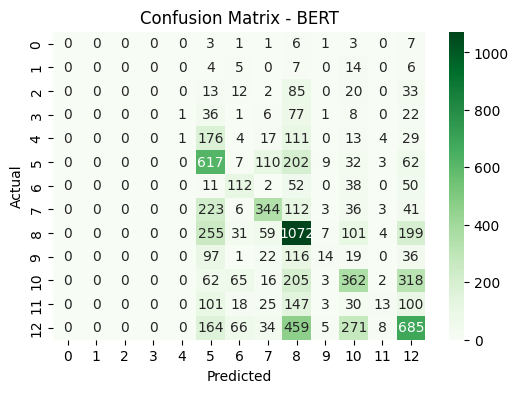

In [32]:
cm_bert = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BERT")
plt.show()


In [36]:
# Save trained model and tokenizer properly (HuggingFace format)

model.save_pretrained("bert_model")
tokenizer.save_pretrained("bert_model")

print("Model and tokenizer saved successfully!")


Model and tokenizer saved successfully!


## Model Comparison

| Model | Approach | Context Awareness | Accuracy |
|------|--------|------------------|----------|
| TF-IDF + Logistic Regression | Statistical | ❌ No | 0.346 |
| BERT (Fine-tuned) | Transformer-based | ✅ Yes | 0.407 |


This project implemented emotion detection from text using two approaches.
The TF-IDF based model served as a baseline and achieved moderate accuracy
due to lack of contextual understanding.

The BERT-based model, which captures semantic and contextual information,
outperformed the baseline despite limited fine-tuning caused by hardware constraints.
This demonstrates the effectiveness of transformer-based models for emotion detection tasks.


## LLM-Inspired Context Generation Layer


S / S1 (Sentence)
   ↓
LLM
   ↓
Context
   ↓
BERT
   ↓
Classify


In [33]:
# LLM-inspired Context Generation Module

def llm_context_generator(sentence):
    sentence = sentence.lower()
    context = sentence

    # Handle negation (important for emotion)
    if "not" in sentence or "never" in sentence or "no " in sentence:
        context += " expressing negative or opposite emotion"

    # Emotion cue enrichment
    emotion_cues = {
        "happy": "positive emotion joy",
        "sad": "negative emotion sadness",
        "angry": "negative emotion anger",
        "fear": "emotion fear anxiety",
        "love": "emotion love affection",
        "hate": "emotion hate anger",
        "excited": "emotion excitement",
        "disappointed": "emotion disappointment"
    }

    for word, cue in emotion_cues.items():
        if word in sentence:
            context += f" {cue}"

    return context


In [34]:
df['context_text'] = df['content'].apply(llm_context_generator)

df[['content', 'context_text']].head()


,content,context_text
0,@tiffanylue i know i was listenin to bad habi...,@tiffanylue i know i was listenin to bad habi...
1,Layin n bed with a headache ughhhh...waitin o...,layin n bed with a headache ughhhh...waitin o...
2,Funeral ceremony...gloomy friday...,funeral ceremony...gloomy friday...
3,wants to hang out with friends SOON!,wants to hang out with friends soon!
4,@dannycastillo We want to trade with someone w...,@dannycastillo we want to trade with someone w...


In [35]:
texts = df['context_text'].values


## Add SHAP Explainer (BERT Compatible)

In [41]:
import sys
print(sys.executable)



c:\ProgramData\anaconda3\python.exe
